<a href="https://colab.research.google.com/github/Priya-DharshiniRamesh/24ADI006_DEEP-LEARNING/blob/main/DL_Multi_Layer_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Multi-Layer Perceptron  (MLP)**

**Name:** Priya Dharshini R  
**Roll No.:** 24BAD092  





Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_train): (60000,)
Feature matrix (x_test): (10000, 28, 28)
Target matrix (y_test): (10000,)


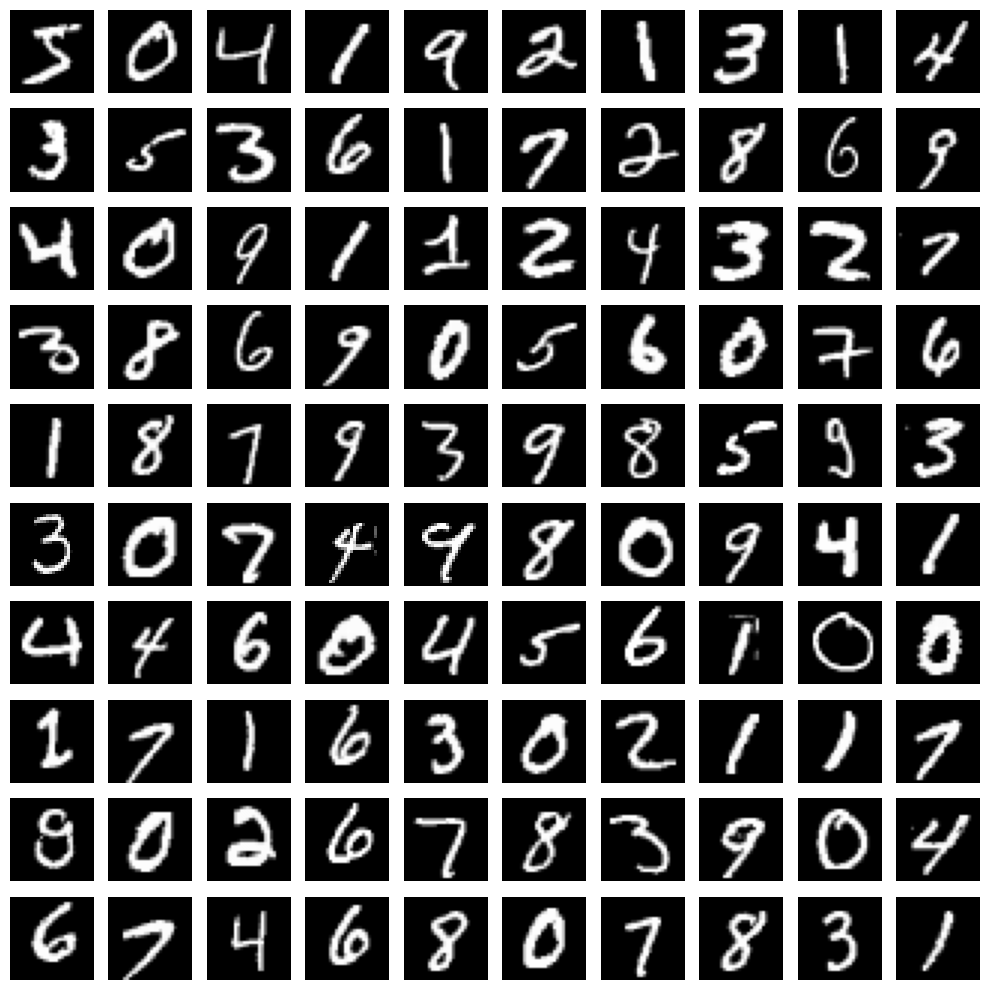

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.7408 - loss: 1.0184 - val_accuracy: 0.8984 - val_loss: 0.3548
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9077 - loss: 0.3159 - val_accuracy: 0.9256 - val_loss: 0.2529
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9318 - loss: 0.2353 - val_accuracy: 0.9407 - val_loss: 0.2034
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9450 - loss: 0.1928 - val_accuracy: 0.9498 - val_loss: 0.1757
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9536 - loss: 0.1618 - val_accuracy: 0.9550 - val_loss: 0.1575
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9595 - loss: 0.1404 - val_accuracy: 0.9599 - val_loss: 0.1437
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9662 - loss: 0.1202 - val_accuracy: 0.9638 - val_loss: 0.1308
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9703 - loss: 0.1061 - val_accuracy: 0.9647 - v

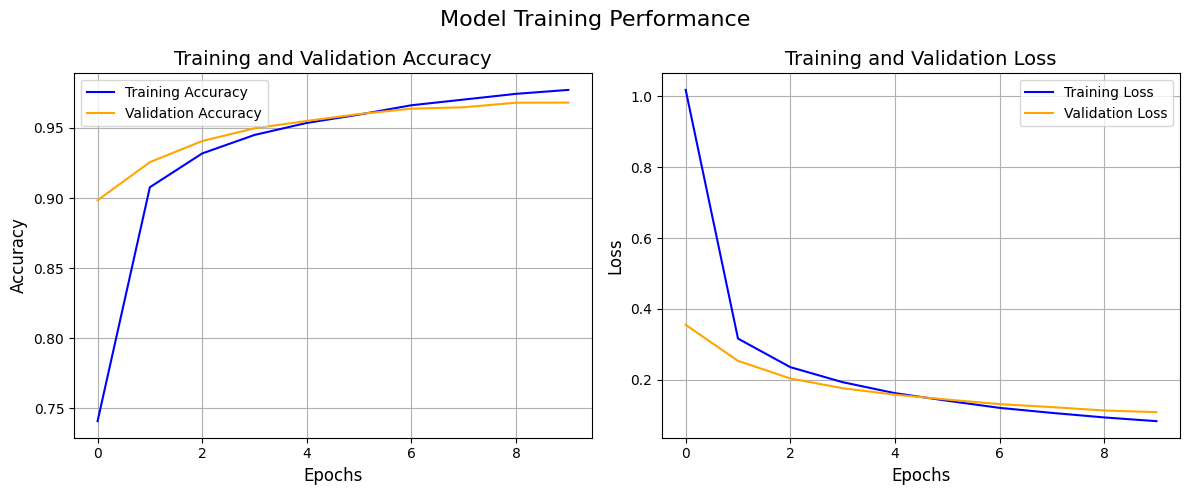

In [3]:
"""
Multi-Layer Perceptron (MLP) for MNIST Digit Classification
Builds, trains, and evaluates a simple MLP using TensorFlow/Keras.
"""

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense


# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


# 2. Normalize the image data (pixel values: 0-255 -> 0-1)
gray_scale = 255
x_train = x_train.astype('float32') / gray_scale
x_test = x_test.astype('float32') / gray_scale

print("Feature matrix (x_train):", x_train.shape)
print("Target matrix (y_train):", y_train.shape)
print("Feature matrix (x_test):", x_test.shape)
print("Target matrix (y_test):", y_test.shape)


# 3. Visualize the first 100 training images
fig, ax = plt.subplots(10, 10, figsize=(10, 10))

k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k], cmap='gray')
        ax[i][j].axis('off')
        k += 1

plt.tight_layout()
plt.savefig('sample_digits.png')
plt.show()


# 4. Build the MLP model
#    Input -> Flatten -> Dense(256, relu) -> Dense(128, relu) -> Dense(10, softmax)
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()


# 5. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# 6. Train the model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=2000,
    validation_split=0.2
)


# 7. Evaluate the model on test data
results = model.evaluate(x_test, y_test, verbose=0)

print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print(f"Test Accuracy: {results[1] * 100:.2f}%")


# 8. Plot training/validation accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.savefig('training_performance.png')
plt.show()